# Example: Reading and Combining the Rubin WFD Stellar-Masked Map

This notebook provides a simple, standalone tutorial showing how to:
1. **Load** the HEALPix fractional footprint map (`rubin_wfd_stellar_masked_nside64.fits`).
2. **Apply completeness threshold cuts** (e.g. `cut >= 0.5` or `0.8`).
3. **Load the SFD dust extinction map** ($E(B-V)$).
4. **Combine the footprint with dust extinction cuts** (e.g. nominal $E(B-V) \le 0.12$ or strict $E(B-V) \le 0.08$) and compute the resulting usable sky area in $\text{deg}^2$.

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from rubin_scheduler.scheduler.utils import CurrentAreaMap

## Step 1: Read the HEALPix Map
The map is saved in standard HEALPix FITS format at $N_{\rm side}=64$ (Equatorial ICRS, RING ordering).
* **Pixel values**: Usable unmasked fraction $\in [0.0, 1.0]$ (fraction of pixel area free of bright stars).
* **Unobserved pixels**: Marked with standard `hp.UNSEEN`.

In [2]:
fits_path = "rubin_wfd_stellar_masked_nside64.fits"

# Read the fractional footprint map
wfd_frac = hp.read_map(fits_path, dtype=np.float32)
nside = hp.npix2nside(len(wfd_frac))
pix_area_deg2 = hp.nside2pixarea(nside, degrees=True)

valid_pixels = (wfd_frac != hp.UNSEEN)

print(f"Loaded HEALPix Map: {fits_path}")
print(f"  - NSIDE:                {nside}")
print(f"  - Single pixel area:    {pix_area_deg2:.4f} deg²")
print(f"  - Valid WFD pixels:     {np.sum(valid_pixels):,}")
print(f"  - Gross Footprint area: {np.sum(valid_pixels) * pix_area_deg2:,.1f} deg²")
print(f"  - Effective Area (sum): {np.sum(wfd_frac[valid_pixels]) * pix_area_deg2:,.1f} deg²")

Loaded HEALPix Map: rubin_wfd_stellar_masked_nside64.fits
  - NSIDE:                64
  - Single pixel area:    0.8393 deg²
  - Valid WFD pixels:     23,664
  - Gross Footprint area: 19,861.0 deg²
  - Effective Area (sum): 14,492.6 deg²


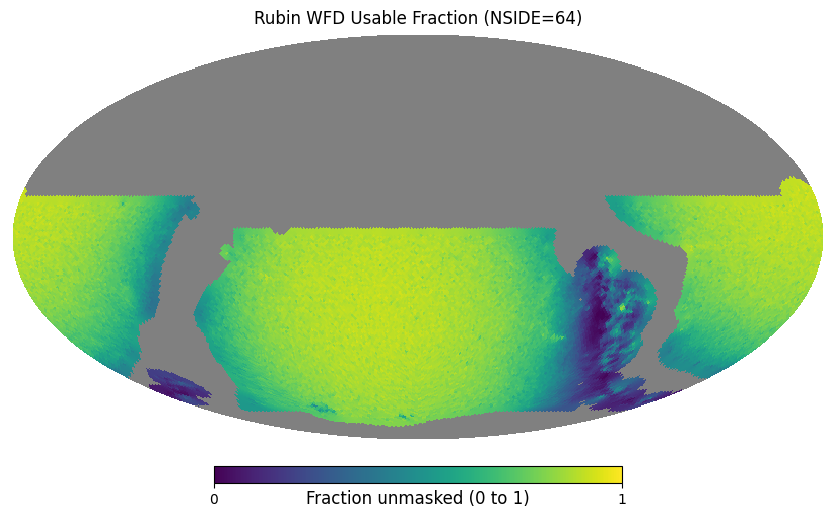

In [3]:
# Visualize the continuous fractional usable area map
hp.mollview(
    wfd_frac,
    title="Rubin WFD Usable Fraction (NSIDE=64)",
    unit="Fraction unmasked (0 to 1)",
    min=0.0,
    max=1.0,
    cmap="viridis"
)

## Step 2: Apply Threshold Cuts (e.g. cut >= 0.5)
Each pixel value indicates the fraction of area that remains usable after excising bright stars.
Applying a threshold cut (e.g. `wfd_frac >= 0.5`) retains only fields where at least 50% of the pixel area is free of bright star halos.

In [4]:
thresholds = [0.0, 0.4, 0.5, 0.6, 0.8]

print("=" * 60)
print(f"{'THRESHOLD CUT':<20} | {'SELECTED PIXELS':<18} | {'AREA [deg²]':<15}")
print("=" * 60)
for t in thresholds:
    mask_t = (wfd_frac != hp.UNSEEN) & (wfd_frac >= t)
    area_t = np.sum(mask_t) * pix_area_deg2
    print(f"wfd_frac >= {t:<7.1f} | {np.sum(mask_t):10,d} pixels | {area_t:10.1f} deg²")
print("=" * 60)

THRESHOLD CUT        | SELECTED PIXELS    | AREA [deg²]    
wfd_frac >= 0.0     |     23,664 pixels |    19861.0 deg²
wfd_frac >= 0.4     |     21,478 pixels |    18026.3 deg²
wfd_frac >= 0.5     |     20,518 pixels |    17220.6 deg²
wfd_frac >= 0.6     |     19,139 pixels |    16063.2 deg²
wfd_frac >= 0.8     |     12,545 pixels |    10528.9 deg²


## Step 3: Load the Dust Extinction Map $E(B-V)$
We load the SFD dust extinction map from Rubin scheduler utilities and project it to the same $N_{\rm side}=64$ grid.

Loaded Dust Map E(B-V) at NSIDE=64
  - Median E(B-V) across sky: 0.0697 mag


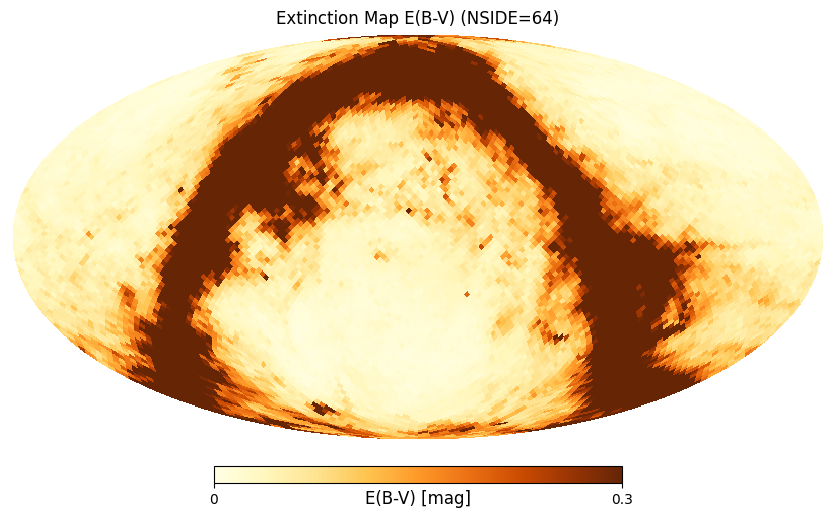

In [5]:
# Load dust map from Rubin CurrentAreaMap
sag = CurrentAreaMap()
dust_raw = getattr(sag, 'dustmap', getattr(sag, 'dust_map', None))

# Upgrade/reproject to NSIDE=64 in Equatorial ICRS
ebv_64 = hp.ud_grade(dust_raw, nside_out=64)

print(f"Loaded Dust Map E(B-V) at NSIDE={hp.npix2nside(len(ebv_64))}")
print(f"  - Median E(B-V) across sky: {np.median(ebv_64):.4f} mag")

hp.mollview(
    ebv_64,
    title="Extinction Map E(B-V) (NSIDE=64)",
    unit="E(B-V) [mag]",
    min=0.0,
    max=0.3,
    cmap="YlOrBr"
)

## Step 4: Combine Footprint Cuts with Dust Extinction Cuts
Now we combine the stellar-masked footprint with different dust extinction cuts:
1. **Nominal Extragalactic Cut**: `(wfd_frac >= 0.5) & (ebv_64 <= 0.12)`
2. **Strict Dust Cut**: `(wfd_frac >= 0.5) & (ebv_64 <= 0.08)`

In [6]:
# Usable footprint mask with cut >= 0.5
wfd_clean_05 = (wfd_frac != hp.UNSEEN) & (wfd_frac >= 0.5)

# 1. Nominal dust cut (E(B-V) <= 0.12)
mask_dust_012 = wfd_clean_05 & (ebv_64 <= 0.12)
area_dust_012 = np.sum(mask_dust_012) * pix_area_deg2

# 2. Strict dust cut (E(B-V) <= 0.08)
mask_dust_008 = wfd_clean_05 & (ebv_64 <= 0.08)
area_dust_008 = np.sum(mask_dust_008) * pix_area_deg2

print("=" * 72)
print(f"{'SURVEY SELECTION':<36} | {'PIXELS':<14} | {'USABLE AREA':<16}")
print("=" * 72)
print(f"{'WFD Footprint (cut >= 0.5)':<36} | {np.sum(wfd_clean_05):8,d}       | {np.sum(wfd_clean_05) * pix_area_deg2:10.1f} deg²")
print(f"{'Footprint (>=0.5) & E(B-V) <= 0.12':<36} | {np.sum(mask_dust_012):8,d}       | {area_dust_012:10.1f} deg²")
print(f"{'Footprint (>=0.5) & E(B-V) <= 0.08':<36} | {np.sum(mask_dust_008):8,d}       | {area_dust_008:10.1f} deg²")
print("=" * 72)

SURVEY SELECTION                     | PIXELS         | USABLE AREA     
WFD Footprint (cut >= 0.5)           |   20,518       |    17220.6 deg²
Footprint (>=0.5) & E(B-V) <= 0.12   |   18,138       |    15223.1 deg²
Footprint (>=0.5) & E(B-V) <= 0.08   |   15,528       |    13032.6 deg²


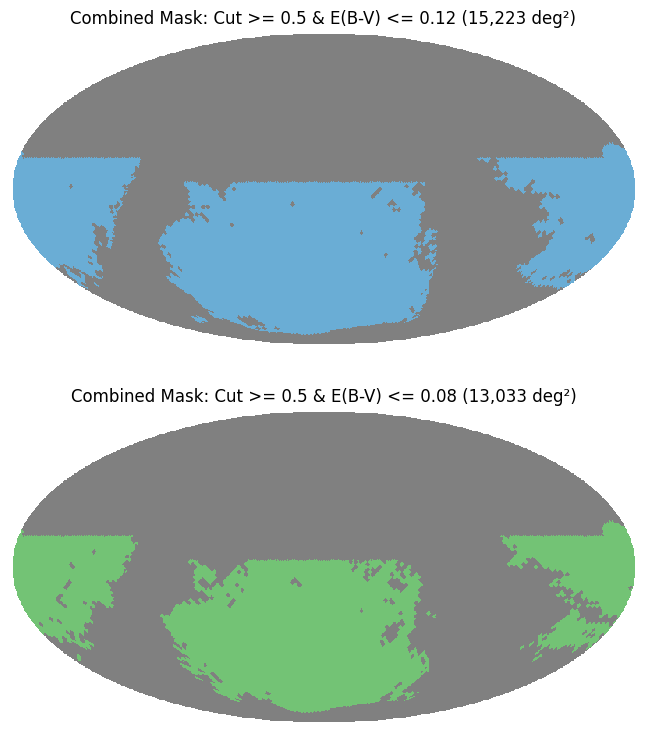

In [7]:
# Plot the resulting combined masks
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 9))

plt.sca(axes[0])
m_plot_012 = np.full(len(ebv_64), hp.UNSEEN)
m_plot_012[mask_dust_012] = 1.0
hp.mollview(
    m_plot_012,
    hold=True,
    title=f"Combined Mask: Cut >= 0.5 & E(B-V) <= 0.12 ({area_dust_012:,.0f} deg²)",
    cbar=False,
    cmap="Blues"
)

plt.sca(axes[1])
m_plot_008 = np.full(len(ebv_64), hp.UNSEEN)
m_plot_008[mask_dust_008] = 1.0
hp.mollview(
    m_plot_008,
    hold=True,
    title=f"Combined Mask: Cut >= 0.5 & E(B-V) <= 0.08 ({area_dust_008:,.0f} deg²)",
    cbar=False,
    cmap="Greens"
)

plt.show()